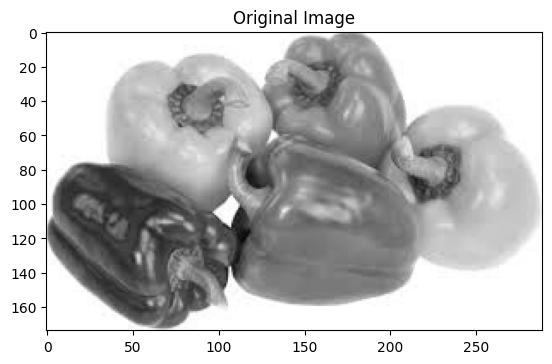

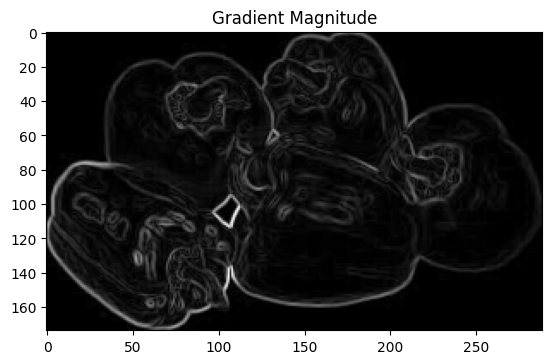

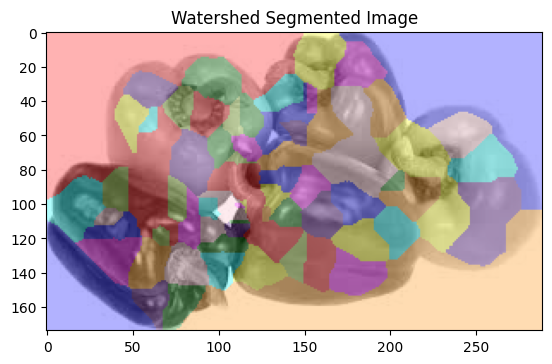

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, morphology, segmentation, color, util
from scipy import ndimage as ndi

img = io.imread('peppers.jpeg')
if img.ndim == 3:
    gray = color.rgb2gray(img)
else:
    gray = img

plt.figure(); plt.imshow(gray, cmap='gray'); plt.title('Original Image')

gmag = filters.sobel(gray)
plt.figure(); plt.imshow(gmag, cmap='gray'); plt.title('Gradient Magnitude')

se = morphology.disk(2)
Ie = morphology.erosion(gray, se)
Iobr = morphology.reconstruction(Ie, gray)

Iobrd = morphology.dilation(Iobr, se)
Iobrcbr = morphology.reconstruction(util.invert(Iobrd), util.invert(Iobr))
Iobrcbr = util.invert(Iobrcbr)

fgm = morphology.local_maxima(Iobrcbr)

markers, _ = ndi.label(fgm)

D = ndi.distance_transform_edt(~fgm)
grad2 = gmag.copy()
grad2[D == 0] = grad2.max()

L = segmentation.watershed(grad2, markers=markers)
Lrgb = color.label2rgb(L, image=gray, bg_label=0)

plt.figure(); plt.imshow(Lrgb); plt.title('Watershed Segmented Image'); plt.show()
